In [1]:
import cfe

cfe.logger.setLevel("DEBUG")

# cfe.settings.backend = "cfe_docker"
cfe.settings.backend = "conda"

[09/28/2025 03:48:41] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

In [ ]:
fadata = cfe.data.read_pancrease()

fadata = cfe.data.read_h5ad("../../tests/data/pancrease_scvelo_500_fadata.h5ad")
fadata.add_prior_information(start_cell="cell_000")

fadata

                      DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             
                      DEBUG    recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                  
                      DEBUG    recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                        
                      DEBUG    parse 'MilestoneWrapper' object for ref                                                                                                                                  


AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    uns: 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'count', 'expression', 'spliced', 'unspliced'

In [3]:
method = cfe.method.FateMethod(method_name="dynamo")
method.infer_trajectory(fadata, parameters={"repreprocess": True})

                      DEBUG    CondaBackend __init__                                                                                                                                                    
[09/28/2025 03:48:42] DEBUG    Conda environment 'dynamo' is available: Python 3.10.18                                                                                                                  
[09/28/2025 03:48:44] DEBUG    Loaded function 'dynamo': <function dynamo at 0x7294077c9d80>                                                                                                            
                      INFO     method backend loaded: CondaBackend: dynamo in conda env 'dynamo'                                                                                                        
                      DEBUG    merged parameters: {'repreprocess': True}                                                                                                                            

                      DEBUG    extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                              
                      DEBUG    plot_trajectory                                                                                                                                                          
                      DEBUG    calculate new trajectory embedding for model_name:None, basis:X_umap.                                                                                                    
                      DEBUG    add waypoints                                                                                                                                                            
                      DEBUG    FateAnnData add_waypoints                                                                                                                                            

<Axes: title={'center': 'clusters'}, xlabel='X_umap1', ylabel='X_umap2'>

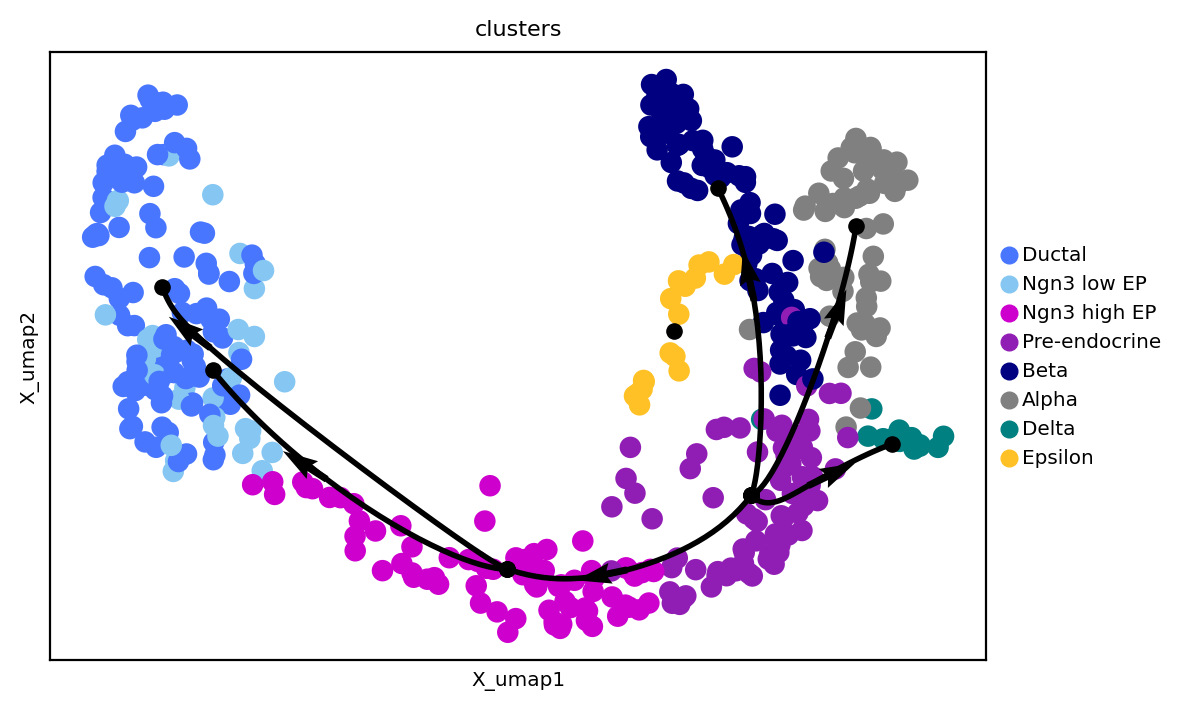

In [4]:
# fix for isolated milestones and cells.
cfe.plot.plot_trajectory(fadata, color="clusters")